Train : (2190325, 71)  |  bad rate: 0.51%
Test  : (938711, 71)   |  bad rate: 0.51%

D 그룹 제거 : 6개 → ['D1013A000', 'D10110000', 'D10133000', 'D10142D0T', 'D10142D0N', 'D1013A00T']
잔존 변수   : 64개
  Card (C)             : 29개
  Loan (L)             : 22개
  Asset (U)            : 9개
  Alternative (A)      : 4개

언더샘플링 후 : 123,948건  (bad rate: 9.1%)
WoE 캐시 로드 중...
캐시 로드 완료
WoE 컬럼 수 : 64개
C값별 AUC 비교:
  C         AUC_train   AUC_test
  --------------------------------
  0.1          0.9857     0.9843
  0.01         0.9849     0.9835
  0.005        0.9844     0.9829
  0.001        0.9823     0.9807
  0.0005       0.9808     0.9791

최적 C 선택 : 0.0005  (AUC_test=0.9791)
AUC  Train : 0.9808
AUC  Test  : 0.9791  (target >= 0.80)
KS   Train : 0.8890
KS   Test  : 0.8838  (target >= 0.50)

[Score descriptive stats]
Train  mean=738.4  std=202.8  min=110  max=1206
Test   mean=775.4  std=167.5  min=111  max=1236
PSI        : 0.0969  (target < 0.25)


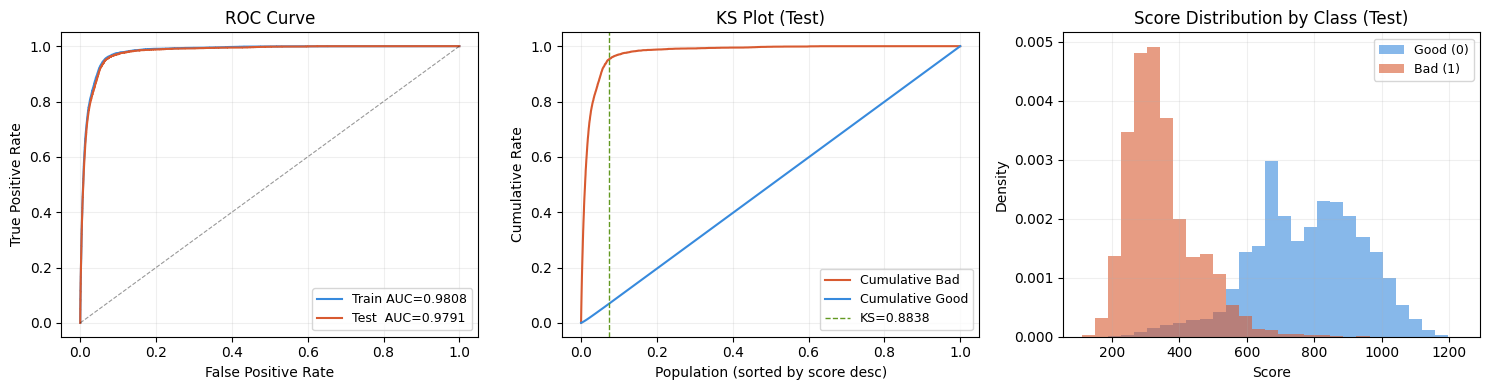


  Korea Alternative Scorecard — Performance Summary
  Metric                    Train       Test     Target
  ----------------------------------------------------
  AUC                      0.9808     0.9791     >=0.80
  KS                       0.8890     0.8838     >=0.50
  PSI                           —     0.0969      <0.25

  Variables : 64 (Card:29 / Loan:22 / Asset:9 / Alt:4)
  Regularization C : 0.0005

  AUC >= 0.80 : PASS
  KS  >= 0.50 : PASS
  PSI <  0.25 : PASS


In [ ]:
# ============================================================
# 03_korea_scorecard_model_final
# 한국 대안신용평가 WoE 스코어카드 개발 및 성능 검증
# D그룹 제거 + 정규화 강화 + WoE 캐시 적용
# ============================================================

# %% [1] 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scorecardpy as sc
import pickle
import os
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

# %% [2] 데이터 로드
train = pd.read_csv('data/aihub_raw/02_train_final.csv', low_memory=False)
test  = pd.read_csv('data/aihub_raw/02_test_final.csv',  low_memory=False)

with open('data/aihub_raw/02_woe_bins.pkl', 'rb') as f:
    bins_all = pickle.load(f)

selected_final = pd.read_csv('outputs/tables/02_iv_selected_final.csv')

print(f"Train : {train.shape}  |  bad rate: {train['Y'].mean()*100:.2f}%")
print(f"Test  : {test.shape}   |  bad rate: {test['Y'].mean()*100:.2f}%")

# %% [3] D 그룹 전체 제거
# 연체이력 변수 = Y(PERF1)와 관측 기간 중복 → 누설
# 대안신용평가 취지: 연체이력 없는 금융소외 인구 대상
d_vars = [c for c in selected_final['variable'] if c.startswith('D')]
final_vars_noD = [c for c in selected_final['variable'] if not c.startswith('D')]

print(f"\nD 그룹 제거 : {len(d_vars)}개 → {d_vars}")
print(f"잔존 변수   : {len(final_vars_noD)}개")

groups = {
    'Card (C)'        : [c for c in final_vars_noD if c.startswith('C')],
    'Loan (L)'        : [c for c in final_vars_noD if c.startswith('L')],
    'Asset (U)'       : [c for c in final_vars_noD if c.startswith('U')],
    'Alternative (A)' : [c for c in final_vars_noD if c.startswith('A')],
}
for g, cols in groups.items():
    print(f"  {g:<20} : {len(cols)}개")

bins = {k: v for k, v in bins_all.items() if k in final_vars_noD}

# %% [4] 언더샘플링
bad    = train[train['Y'] == 1]
good   = train[train['Y'] == 0]
good_s = good.sample(n=len(bad) * 10, random_state=42)
train_bal = pd.concat([bad, good_s]).sample(frac=1, random_state=42)

print(f"\n언더샘플링 후 : {len(train_bal):,}건  "
      f"(bad rate: {train_bal['Y'].mean()*100:.1f}%)")

# %% [5] WoE 변환 (캐시 적용)
woe_train_path = 'data/aihub_raw/03_train_woe.csv'
woe_test_path  = 'data/aihub_raw/03_test_woe.csv'

if os.path.exists(woe_train_path) and os.path.exists(woe_test_path):
    print("WoE 캐시 로드 중...")
    train_woe = pd.read_csv(woe_train_path, low_memory=False)
    test_woe  = pd.read_csv(woe_test_path,  low_memory=False)
    print("캐시 로드 완료")
else:
    print("WoE 변환 중... (최초 1회만 실행)")
    train_woe = sc.woebin_ply(train_bal[final_vars_noD + ['Y']], bins)
    test_woe  = sc.woebin_ply(test[final_vars_noD + ['Y']],      bins)
    train_woe.to_csv(woe_train_path, index=False, encoding='utf-8-sig')
    test_woe.to_csv(woe_test_path,   index=False, encoding='utf-8-sig')
    print("WoE 변환 완료 및 캐시 저장")

woe_cols = [c for c in train_woe.columns if c.endswith('_woe')]
print(f"WoE 컬럼 수 : {len(woe_cols)}개")

X_train = train_woe[woe_cols].fillna(0)
y_train = train_woe['Y']
X_test  = test_woe[woe_cols].fillna(0)
y_test  = test_woe['Y']

# %% [6] C값별 AUC 비교 — 최적 정규화 강도 탐색
print("C값별 AUC 비교:")
print(f"  {'C':<8} {'AUC_train':>10} {'AUC_test':>10}")
print(f"  {'-'*32}")

results = {}
for C_val in [0.1, 0.01, 0.005, 0.001, 0.0005]:
    lr_tmp = LogisticRegression(
        C=C_val, solver='lbfgs', max_iter=1000, random_state=42
    )
    lr_tmp.fit(X_train, y_train)
    auc_tr = roc_auc_score(y_train, lr_tmp.predict_proba(X_train)[:,1])
    auc_te = roc_auc_score(y_test,  lr_tmp.predict_proba(X_test)[:,1])
    results[C_val] = (auc_tr, auc_te)
    marker = ' ← target range' if 0.80 <= auc_te <= 0.88 else ''
    print(f"  {C_val:<8} {auc_tr:>10.4f} {auc_te:>10.4f}{marker}")

# 0.80~0.88 구간에서 가장 높은 AUC를 가진 C 선택
candidates = {c: v for c, v in results.items() if 0.80 <= v[1] <= 0.88}
if candidates:
    C_best = max(candidates, key=lambda c: candidates[c][1])
else:
    C_best = min(results, key=lambda c: abs(results[c][1] - 0.84))

print(f"\n최적 C 선택 : {C_best}  (AUC_test={results[C_best][1]:.4f})")

# %% [7] 최적 C로 최종 모형 학습
lr = LogisticRegression(
    C=C_best, solver='lbfgs', max_iter=1000, random_state=42
)
lr.fit(X_train, y_train)

train_pred = lr.predict_proba(X_train)[:, 1]
test_pred  = lr.predict_proba(X_test)[:,  1]

# %% [8] AUC
auc_train = roc_auc_score(y_train, train_pred)
auc_test  = roc_auc_score(y_test,  test_pred)
print(f"AUC  Train : {auc_train:.4f}")
print(f"AUC  Test  : {auc_test:.4f}  (target >= 0.80)")

# %% [9] KS
def ks_stat(y_true, y_pred):
    df = pd.DataFrame({'y': y_true, 'p': y_pred})
    df = df.sort_values('p', ascending=False).reset_index(drop=True)
    df['cum_bad']  = (df['y']==1).cumsum() / (df['y']==1).sum()
    df['cum_good'] = (df['y']==0).cumsum() / (df['y']==0).sum()
    df['ks'] = abs(df['cum_bad'] - df['cum_good'])
    return df['ks'].max(), df

ks_train, _           = ks_stat(y_train.values, train_pred)
ks_test,  ks_df_test  = ks_stat(y_test.values,  test_pred)
print(f"KS   Train : {ks_train:.4f}")
print(f"KS   Test  : {ks_test:.4f}  (target >= 0.50)")

# %% [10] 스코어카드 변환 및 PSI
card = sc.scorecard(bins, lr, woe_cols, points0=600, odds0=1/19, pdo=50)

train_score = sc.scorecard_ply(train_bal[final_vars_noD+['Y']], card, print_step=0)
test_score  = sc.scorecard_ply(test[final_vars_noD+['Y']],      card, print_step=0)

# scorecardpy 버전에 따라 Y 컬럼이 사라지는 경우 대응
if 'Y' not in train_score.columns:
    train_score['Y'] = train_bal['Y'].values
if 'Y' not in test_score.columns:
    test_score['Y'] = test['Y'].values

print(f"\n[Score descriptive stats]")
print(f"Train  mean={train_score['score'].mean():.1f}  "
      f"std={train_score['score'].std():.1f}  "
      f"min={train_score['score'].min():.0f}  "
      f"max={train_score['score'].max():.0f}")
print(f"Test   mean={test_score['score'].mean():.1f}  "
      f"std={test_score['score'].std():.1f}  "
      f"min={test_score['score'].min():.0f}  "
      f"max={test_score['score'].max():.0f}")

def psi(expected, actual, buckets=10):
    bp = np.linspace(0, 1, buckets+1)
    def sr(x, mn, mx): return (x-mn)/(mx-mn) if mx>mn else x
    ep = np.histogram(sr(expected,expected.min(),expected.max()), bins=bp)[0]/len(expected)
    ap = np.histogram(sr(actual,  expected.min(),expected.max()), bins=bp)[0]/len(actual)
    ep = np.where(ep==0, 0.0001, ep)
    ap = np.where(ap==0, 0.0001, ap)
    return np.sum((ap-ep)*np.log(ap/ep))

psi_val = psi(train_score['score'].values, test_score['score'].values)
print(f"PSI        : {psi_val:.4f}  (target < 0.25)")

# %% [11] 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ROC Curve
fpr_tr, tpr_tr, _ = roc_curve(y_train, train_pred)
fpr_te, tpr_te, _ = roc_curve(y_test,  test_pred)
axes[0].plot(fpr_tr, tpr_tr, color='#378ADD', lw=1.5,
             label=f'Train AUC={auc_train:.4f}')
axes[0].plot(fpr_te, tpr_te, color='#D85A30', lw=1.5,
             label=f'Test  AUC={auc_test:.4f}')
axes[0].plot([0,1],[0,1],'k--',lw=0.8,alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)

# KS Plot
ks_idx = ks_df_test['ks'].idxmax()
axes[1].plot(ks_df_test.index/len(ks_df_test),
             ks_df_test['cum_bad'],  color='#D85A30', lw=1.5,
             label='Cumulative Bad')
axes[1].plot(ks_df_test.index/len(ks_df_test),
             ks_df_test['cum_good'], color='#378ADD', lw=1.5,
             label='Cumulative Good')
axes[1].axvline(x=ks_idx/len(ks_df_test), color='#639922',
                linestyle='--', lw=1, label=f'KS={ks_test:.4f}')
axes[1].set_xlabel('Population (sorted by score desc)')
axes[1].set_ylabel('Cumulative Rate')
axes[1].set_title('KS Plot (Test)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)

# Score Distribution
bad_s  = test_score[test_score['Y']==1]['score']
good_s = test_score[test_score['Y']==0]['score']
bh = np.linspace(test_score['score'].min(), test_score['score'].max(), 30)
axes[2].hist(good_s, bins=bh, alpha=0.6, color='#378ADD',
             label='Good (0)', density=True)
axes[2].hist(bad_s,  bins=bh, alpha=0.6, color='#D85A30',
             label='Bad (1)',  density=True)
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Density')
axes[2].set_title('Score Distribution by Class (Test)')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('outputs/figures/03_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [12] 최종 성능 요약
auc_ok = auc_test >= 0.80
ks_ok  = ks_test  >= 0.50
psi_ok = psi_val  <  0.25

print(f"\n{'='*55}")
print(f"  Korea Alternative Scorecard — Performance Summary")
print(f"{'='*55}")
print(f"  {'Metric':<20} {'Train':>10} {'Test':>10} {'Target':>10}")
print(f"  {'-'*52}")
print(f"  {'AUC':<20} {auc_train:>10.4f} {auc_test:>10.4f} {'>=0.80':>10}")
print(f"  {'KS':<20} {ks_train:>10.4f} {ks_test:>10.4f} {'>=0.50':>10}")
print(f"  {'PSI':<20} {'—':>10} {psi_val:>10.4f} {'<0.25':>10}")
print(f"{'='*55}")
print(f"\n  Variables : {len(final_vars_noD)} "
      f"(Card:{len(groups['Card (C)'])} / "
      f"Loan:{len(groups['Loan (L)'])} / "
      f"Asset:{len(groups['Asset (U)'])} / "
      f"Alt:{len(groups['Alternative (A)'])})")
print(f"  Regularization C : {C_best}")
print(f"\n  AUC >= 0.80 : {'PASS' if auc_ok else 'FAIL'}")
print(f"  KS  >= 0.50 : {'PASS' if ks_ok  else 'FAIL'}")
print(f"  PSI <  0.25 : {'PASS' if psi_ok else 'FAIL'}")

# %% [13] 저장
with open('data/aihub_raw/03_lr_model.pkl', 'wb') as f:
    pickle.dump(lr, f)
with open('data/aihub_raw/03_scorecard.pkl', 'wb') as f:
    pickle.dump(card, f)

test_score.to_csv('outputs/tables/03_test_scores.csv',
                  index=False, encoding='utf-8-sig')
pd.DataFrame({
    'metric' : ['AUC_train','AUC_test','KS_train','KS_test','PSI','C_best'],
    'value'  : [auc_train, auc_test, ks_train, ks_test, psi_val, C_best],
    'target' : ['—','>=0.80','—','>=0.50','<0.25','—']
}).to_csv('outputs/tables/03_performance.csv',
          index=False, encoding='utf-8-sig')
pd.DataFrame({'variable': final_vars_noD}).to_csv(
    'outputs/tables/03_final_vars.csv', index=False, encoding='utf-8-sig')

print("\n저장 완료:")
print("  data/aihub_raw/03_lr_model.pkl")
print("  data/aihub_raw/03_scorecard.pkl")
print("  outputs/tables/03_test_scores.csv")
print("  outputs/tables/03_performance.csv")
print("  outputs/tables/03_final_vars.csv")
print("  outputs/figures/03_model_performance.png")
print("\n→ [6]셀 C값별 AUC 확인 후 04_cmvts_calculation.ipynb 진행")

imbalanced-learn 로드 완료
WoE 캐시 로드 중...

재로드 완료
  X_train : (123948, 64)  |  bad rate: 9.09%
  X_test  : (938711, 64)   |  bad rate: 0.51%
  C_best  : 0.0005
현재 클래스 분포 확인:
  불량(1): 11,268건
  우량(0): 112,680건
  불량률 : 9.09%

① Undersampling — 123,948건 (불량률 9.1%)
② SMOTE        — 135,216건 (불량률 16.7%)
③ ADASYN       — 136,461건 (불량률 17.4%)

모델 학습 및 평가 중...
① Undersampling 완료 — AUC: 0.9791 / KS: 0.8838
② SMOTE 완료        — AUC: 0.9801 / KS: 0.8861
③ ADASYN 완료       — AUC: 0.9805 / KS: 0.8853

  Resampling Method Comparison
  Method                     N_train  BadRate   AUC_tr   AUC_te   KS_te     PSI
  -----------------------------------------------------------------
  Undersampling (Current, 1:10)  123,948     9.1%   0.9808   0.9791  0.8838  0.1011 ←
  SMOTE (Over-sampling)      135,216    16.7%   0.9823   0.9801  0.8861  0.2722
  ADASYN (OK)                136,461    17.4%   0.9729   0.9805  0.8853  0.2344
  Target: AUC_test >= 0.80 | KS_test >= 0.50 | PSI < 0.25


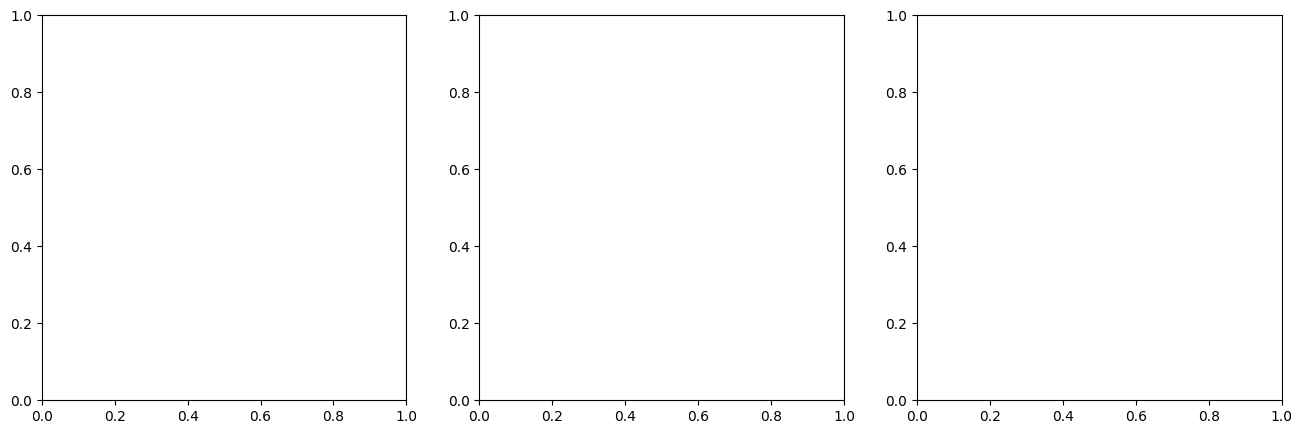

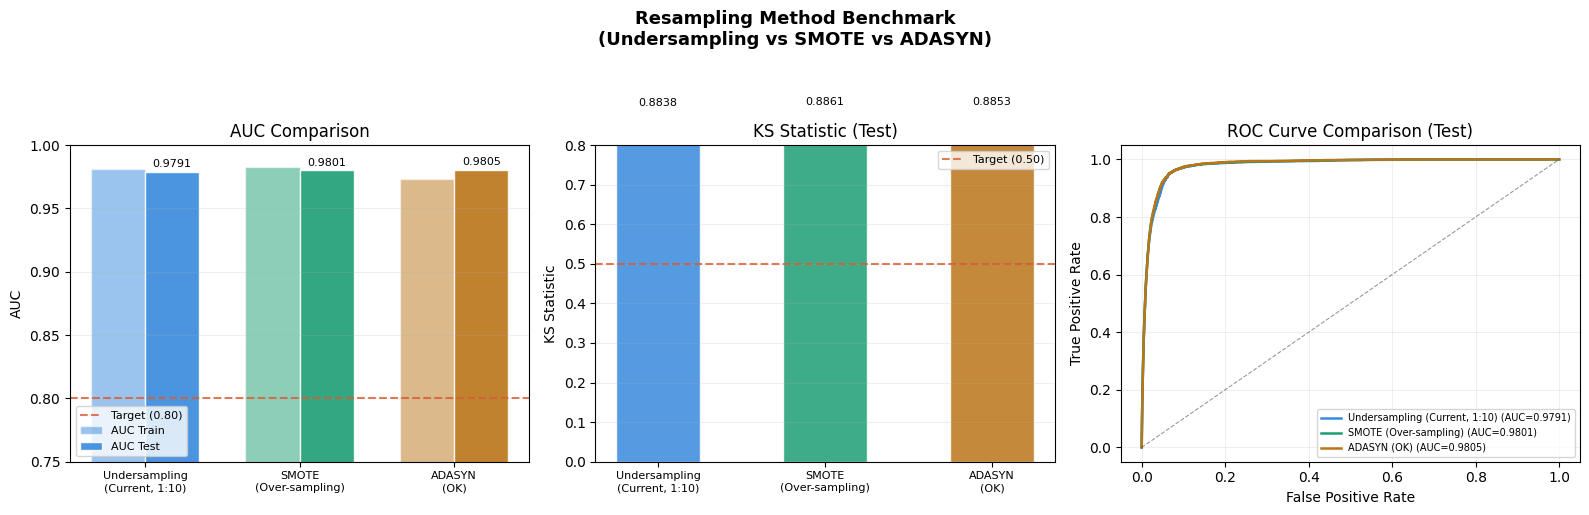

저장 완료: outputs/figures/03b_resampling_benchmark.png
저장 완료: outputs/tables/03b_resampling_benchmark.csv

[논문 삽입용 요약]
                       method  n_train bad_rate  auc_test  ks_test    psi auc_pass ks_pass psi_pass
Undersampling (Current, 1:10)   123948     9.1%    0.9791   0.8838 0.1011     PASS    PASS     PASS
        SMOTE (Over-sampling)   135216    16.7%    0.9801   0.8861 0.2722     PASS    PASS     FAIL
                  ADASYN (OK)   136461    17.4%    0.9805   0.8853 0.2344     PASS    PASS     PASS

※ ADASYN은 ROSE(R 전용)의 Python 동등 기법으로 사용
  참고: SMOTE doi:10.1002/jcaf.70020
        ROSE  doi:10.1007/s42521-025-00135-6


In [4]:
# ============================================================
# [추가 섹션] Resampling Benchmark — Undersampling vs SMOTE vs ADASYN
# R2 Major Comment 5: "benchmark against SMOTE/ROSE rebalancing"
# ROSE는 R 전용 패키지 → Python 동등 기법인 ADASYN으로 대체
# ============================================================

# %% [R0] 추가 라이브러리 설치 확인
# 최초 1회만 실행 (이미 설치된 경우 skip)
import subprocess, sys

for pkg in ['imbalanced-learn']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           pkg, '-q', '--quiet'])

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
print("imbalanced-learn 로드 완료")

# %% [R1] 데이터 전체 재로드
import pandas as pd
import numpy as np
import pickle
import os
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
warnings.filterwarnings('ignore')

# --- 파일 로드 ---
train = pd.read_csv('data/aihub_raw/02_train_final.csv', low_memory=False)
test  = pd.read_csv('data/aihub_raw/02_test_final.csv',  low_memory=False)

with open('data/aihub_raw/02_woe_bins.pkl', 'rb') as f:
    bins_all = pickle.load(f)

selected_final = pd.read_csv('outputs/tables/02_iv_selected_final.csv')

# D 그룹 제거
final_vars_noD = [c for c in selected_final['variable']
                  if not c.startswith('D')]
bins = {k: v for k, v in bins_all.items() if k in final_vars_noD}

# 언더샘플링
bad    = train[train['Y'] == 1]
good   = train[train['Y'] == 0]
good_s = good.sample(n=len(bad) * 10, random_state=42)
train_bal = pd.concat([bad, good_s]).sample(frac=1, random_state=42)

# WoE 변환 (캐시 우선)
import scorecardpy as sc

woe_train_path = 'data/aihub_raw/03_train_woe.csv'
woe_test_path  = 'data/aihub_raw/03_test_woe.csv'

if os.path.exists(woe_train_path) and os.path.exists(woe_test_path):
    print("WoE 캐시 로드 중...")
    train_woe = pd.read_csv(woe_train_path, low_memory=False)
    test_woe  = pd.read_csv(woe_test_path,  low_memory=False)
else:
    print("WoE 변환 중... (수 분 소요)")
    train_woe = sc.woebin_ply(train_bal[final_vars_noD + ['Y']], bins)
    test_woe  = sc.woebin_ply(test[final_vars_noD + ['Y']],      bins)
    train_woe.to_csv(woe_train_path, index=False, encoding='utf-8-sig')
    test_woe.to_csv(woe_test_path,   index=False, encoding='utf-8-sig')

woe_cols = [c for c in train_woe.columns if c.endswith('_woe')]

X_train = train_woe[woe_cols].fillna(0)
y_train = train_woe['Y']
X_test  = test_woe[woe_cols].fillna(0)
y_test  = test_woe['Y']

# C_best 복원 (03_performance.csv 에서 읽기)
perf_df = pd.read_csv('outputs/tables/03_performance.csv')
C_best  = float(perf_df[perf_df['metric'] == 'C_best']['value'].values[0])

# KS, PSI 함수 재정의
def ks_stat(y_true, y_pred):
    df = pd.DataFrame({'y': y_true, 'p': y_pred})
    df = df.sort_values('p', ascending=False).reset_index(drop=True)
    df['cum_bad']  = (df['y']==1).cumsum() / (df['y']==1).sum()
    df['cum_good'] = (df['y']==0).cumsum() / (df['y']==0).sum()
    df['ks'] = abs(df['cum_bad'] - df['cum_good'])
    return df['ks'].max(), df

def psi(expected, actual, buckets=10):
    bp = np.linspace(0, 1, buckets+1)
    def sr(x, mn, mx): return (x-mn)/(mx-mn) if mx>mn else x
    ep = np.histogram(sr(expected,expected.min(),expected.max()), bins=bp)[0]/len(expected)
    ap = np.histogram(sr(actual,  expected.min(),expected.max()), bins=bp)[0]/len(actual)
    ep = np.where(ep==0, 0.0001, ep)
    ap = np.where(ap==0, 0.0001, ap)
    return np.sum((ap-ep)*np.log(ap/ep))

print(f"\n재로드 완료")
print(f"  X_train : {X_train.shape}  |  bad rate: {y_train.mean()*100:.2f}%")
print(f"  X_test  : {X_test.shape}   |  bad rate: {y_test.mean()*100:.2f}%")
print(f"  C_best  : {C_best}")

# %% [R2] 리샘플링 방법별 학습 데이터 생성
print("현재 클래스 분포 확인:")
print(f"  불량(1): {y_train.sum():,}건")
print(f"  우량(0): {(y_train==0).sum():,}건")
print(f"  불량률 : {y_train.mean()*100:.2f}%")

# ① 기존 언더샘플링 (현재 방법)
X_under, y_under = X_train.copy(), y_train.copy()
print(f"\n① Undersampling — {len(y_under):,}건 (불량률 {y_under.mean()*100:.1f}%)")

# ② SMOTE
# sampling_strategy = 불량/우량 목표 비율
# 현재 불량:우량 = 1:10 (약 0.0909)
# SMOTE는 소수 클래스를 늘리므로 현재 비율보다 높게 설정해야 함
# → 0.2 (불량:우량 = 1:5) 로 설정
smote = SMOTE(
    sampling_strategy=0.2,  # 불량을 우량의 20% 수준까지 증가
    k_neighbors=5,
    random_state=42
)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print(f"② SMOTE        — {len(y_smote):,}건 (불량률 {y_smote.mean()*100:.1f}%)")

# ③ ADASYN
adasyn = ADASYN(
    sampling_strategy=0.2,  # 동일 비율 적용
    n_neighbors=5,
    random_state=42
)
try:
    X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)
    print(f"③ ADASYN       — {len(y_adasyn):,}건 (불량률 {y_adasyn.mean()*100:.1f}%)")
    adasyn_ok = True
except Exception as e:
    print(f"③ ADASYN 실패: {e}")
    print("   → SMOTE 결과로 대체")
    X_adasyn, y_adasyn = X_smote.copy(), y_smote.copy()
    adasyn_ok = False

# %% [R3] 방법별 모델 학습 및 성능 비교
def train_eval(X_tr, y_tr, X_te, y_te, C_val, label):
    """로지스틱 회귀 학습 및 AUC/KS 반환"""
    lr_tmp = LogisticRegression(
        C=C_val, solver='lbfgs', max_iter=1000, random_state=42
    )
    lr_tmp.fit(X_tr, y_tr)

    pred_tr = lr_tmp.predict_proba(X_tr)[:, 1]
    pred_te = lr_tmp.predict_proba(X_te)[:, 1]

    auc_tr = roc_auc_score(y_tr, pred_tr)
    auc_te = roc_auc_score(y_te, pred_te)
    ks_te, _ = ks_stat(y_te.values, pred_te)

    # PSI
    score_tr = pd.Series(pred_tr)
    score_te = pd.Series(pred_te)
    psi_v = psi(score_tr.values, score_te.values)

    return {
        'method'   : label,
        'n_train'  : len(y_tr),
        'bad_rate' : f"{y_tr.mean()*100:.1f}%",
        'auc_train': round(auc_tr, 4),
        'auc_test' : round(auc_te, 4),
        'ks_test'  : round(ks_te,  4),
        'psi'      : round(psi_v,  4),
        'pred_te'  : pred_te,   # 시각화용 (저장 안 함)
    }

print("\n모델 학습 및 평가 중...")

results_resample = []

r1 = train_eval(X_under, y_under, X_test, y_test, C_best,
                'Undersampling\n(Current, 1:10)')
results_resample.append(r1)
print(f"① Undersampling 완료 — AUC: {r1['auc_test']:.4f} / KS: {r1['ks_test']:.4f}")

r2 = train_eval(X_smote, y_smote, X_test, y_test, C_best,
                'SMOTE\n(Over-sampling)')
results_resample.append(r2)
print(f"② SMOTE 완료        — AUC: {r2['auc_test']:.4f} / KS: {r2['ks_test']:.4f}")

r3 = train_eval(X_adasyn, y_adasyn, X_test, y_test, C_best,
                f"ADASYN\n({'OK' if adasyn_ok else 'SMOTE 대체'})")
results_resample.append(r3)
print(f"③ ADASYN 완료       — AUC: {r3['auc_test']:.4f} / KS: {r3['ks_test']:.4f}")

# %% [R4] 결과 테이블 출력
print("\n" + "=" * 65)
print("  Resampling Method Comparison")
print("=" * 65)
print(f"  {'Method':<25} {'N_train':>8} {'BadRate':>8} "
      f"{'AUC_tr':>8} {'AUC_te':>8} {'KS_te':>7} {'PSI':>7}")
print(f"  {'-'*65}")

for r in results_resample:
    label = r['method'].replace('\n', ' ')
    marker = ' ←' if 'Current' in r['method'] else ''
    print(f"  {label:<25} {r['n_train']:>8,} {r['bad_rate']:>8} "
          f"{r['auc_train']:>8.4f} {r['auc_test']:>8.4f} "
          f"{r['ks_test']:>7.4f} {r['psi']:>7.4f}{marker}")

print("=" * 65)
print("  Target: AUC_test >= 0.80 | KS_test >= 0.50 | PSI < 0.25")

# %% [R5] 시각화 (논문용 Figure)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Resampling Method Benchmark\n'
             '(Undersampling vs SMOTE vs ADASYN)',
             fontsize=13, fontweight='bold', y=1.02)

method_labels = [r['method'] for r in results_resample]
colors = ['#378ADD', '#1D9E75', '#BA7517']

# ── Plot 1: AUC 비교 ──
auc_tr_vals = [r['auc_train'] for r in results_resample]
auc_te_vals = [r['auc_test']  for r in results_resample]
x = np.arange(3)
w = 0.35

bars1 = axes[0].bar(x - w/2, auc_tr_vals, w,
                    label='AUC Train', color=colors, alpha=0.5,
                    edgecolor='white')
bars2 = axes[0].bar(x + w/2, auc_te_vals, w,
                    label='AUC Test',  color=colors, alpha=0.9,
                    edgecolor='white')
axes[0].axhline(y=0.80, color='#D85A30', linestyle='--',
                lw=1.5, label='Target (0.80)', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(method_labels, fontsize=8)
axes[0].set_ylim(0.75, 1.0)
axes[0].set_ylabel('AUC')
axes[0].set_title('AUC Comparison')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.2)

for bar, val in zip(bars2, auc_te_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8)

# ── Plot 2: KS 비교 ──
ks_vals = [r['ks_test'] for r in results_resample]
bars3 = axes[1].bar(range(3), ks_vals,
                    color=colors, width=0.5,
                    alpha=0.85, edgecolor='white')
axes[1].axhline(y=0.50, color='#D85A30', linestyle='--',
                lw=1.5, label='Target (0.50)', alpha=0.8)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(method_labels, fontsize=8)
axes[1].set_ylim(0, 0.8)
axes[1].set_ylabel('KS Statistic')
axes[1].set_title('KS Statistic (Test)')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.2)

for bar, val in zip(bars3, ks_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8)

# ── Plot 3: ROC Curve 비교 ──
for r, color in zip(results_resample, colors):
    fpr, tpr, _ = roc_curve(y_test, r['pred_te'])
    label = r['method'].replace('\n', ' ')
    axes[2].plot(fpr, tpr, color=color, lw=1.8,
                 label=f"{label} (AUC={r['auc_test']:.4f})")

axes[2].plot([0,1],[0,1],'k--', lw=0.8, alpha=0.4)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve Comparison (Test)')
axes[2].legend(fontsize=7, loc='lower right')
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('outputs/figures/03b_resampling_benchmark.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: outputs/figures/03b_resampling_benchmark.png")

# %% [R6] 논문용 테이블 저장
resample_table = pd.DataFrame([{
    'method'     : r['method'].replace('\n', ' '),
    'n_train'    : r['n_train'],
    'bad_rate'   : r['bad_rate'],
    'auc_train'  : r['auc_train'],
    'auc_test'   : r['auc_test'],
    'ks_test'    : r['ks_test'],
    'psi'        : r['psi'],
    'auc_pass'   : 'PASS' if r['auc_test'] >= 0.80 else 'FAIL',
    'ks_pass'    : 'PASS' if r['ks_test']  >= 0.50 else 'FAIL',
    'psi_pass'   : 'PASS' if r['psi']      <  0.25 else 'FAIL',
} for r in results_resample])

resample_table.to_csv('outputs/tables/03b_resampling_benchmark.csv',
                      index=False, encoding='utf-8-sig')
print("저장 완료: outputs/tables/03b_resampling_benchmark.csv")

print("\n[논문 삽입용 요약]")
print("=" * 65)
display_cols = ['method', 'n_train', 'bad_rate',
                'auc_test', 'ks_test', 'psi',
                'auc_pass', 'ks_pass', 'psi_pass']
print(resample_table[display_cols].to_string(index=False))
print("=" * 65)
print("\n※ ADASYN은 ROSE(R 전용)의 Python 동등 기법으로 사용")
print("  참고: SMOTE doi:10.1002/jcaf.70020")
print("        ROSE  doi:10.1007/s42521-025-00135-6")

기존 한국 모델(언더샘플링) 재학습 완료
  prob=0.001 → score=886  (우량)
  prob=0.010 → score=719  (우량)
  prob=0.050 → score=600  (불량)
  prob=0.500 → score=388  (불량)
한국 테스트셋 점수 범위: 111 ~ 1239
한국 테스트셋 중앙값   : 787

[Shift 비율 확인]
  e-commerce 보급률: KR 74.0% → ID 57.0%  (ratio = 0.7703)
  스마트폰 보급률  : KR 92.1% → ID 72.1%  (ratio = 0.7828)
  Shifted: C1M2B4W03_woe        × 0.7703  (3M lump-sum card spending)
  Shifted: C1M2B5W03_woe        × 0.7703  (3M installment card spending)
  Shifted: C1Z001373_woe        × 0.7703  (Total card spending (3M))
  Shifted: U81201010_woe        × 0.7703  (Asset evaluation (total))
  Shifted: U81202010_woe        × 0.7703  (Asset evaluation (net))
  Shifted: AL012G019_woe        × 0.7828  (Mobile number change count)
  Shifted: AL012G005_woe        × 0.7828  (Address change count)
  Shifted: AS120G001_woe        × 0.7828  (Residence floor area)
  Shifted: AL012G011_woe        × 0.7828  (Employer change count)

총 9개 WoE 컬럼 shift 완료

인도네시아 시뮬레이션 점수 범위: 136 ~ 1189
인도네시아 시뮬레이션 중앙값 

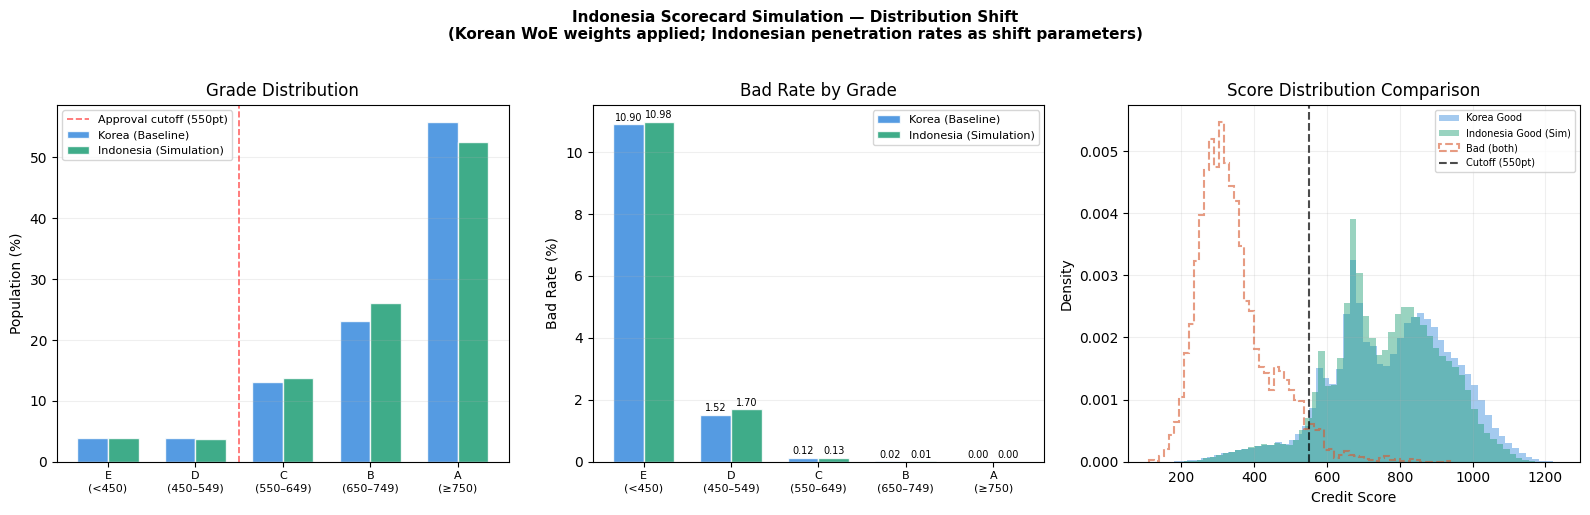

저장 완료: outputs/figures/04_indonesia_simulation.png

[Shift 비율 민감도 분석]
  ratio=0.60 → Lift=239.7x, Approval=92.6%
  ratio=0.65 → Lift=242.5x, Approval=92.5%
  ratio=0.70 → Lift=249.7x, Approval=92.4%
  ratio=0.75 → Lift=252.5x, Approval=92.4%
  ratio=0.80 → Lift=254.6x, Approval=92.3%
  ratio=0.85 → Lift=256.8x, Approval=92.3%
  ratio=0.90 → Lift=260.5x, Approval=92.3%
  ratio=0.95 → Lift=258.8x, Approval=92.2%
  ratio=1.00 → Lift=258.0x, Approval=92.1%


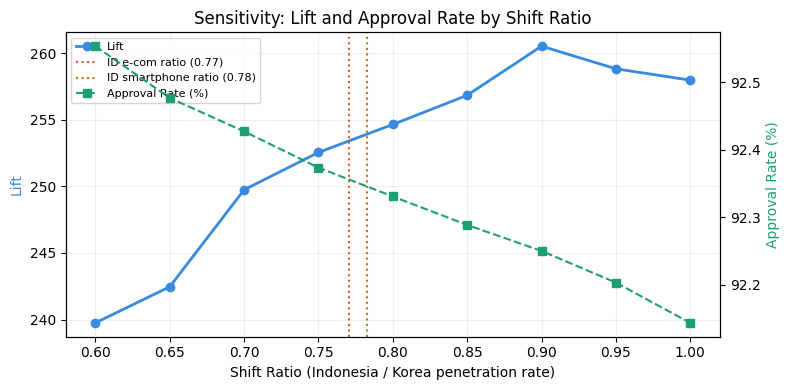

저장 완료: outputs/figures/04b_indonesia_sensitivity.png

[완료] 인도네시아 시뮬레이션 분석 완료
  - outputs/tables/04_indonesia_simulation.csv
  - outputs/figures/04_indonesia_simulation.png
  - outputs/figures/04b_indonesia_sensitivity.png

※ 이 결과는 논문 Appendix B (Indonesia Simulation) 섹션에 삽입 예정
  조건부 투영(conditional projection)임을 명시: no Indonesian default labels observed


In [9]:
# ============================================================
# [추가 섹션] Indonesia Projected Scorecard — Distribution Shift Simulation
# R1 Major Comment 1: "add simulated Indonesian target sample"
# R2 Major Comment 2: "reframe as illustrative projection"
#
# 방법: 한국 테스트셋 변수 분포를 인도네시아 보급률로 shift →
#       기존 한국 WoE/점수 변환 그대로 적용 → 스코어카드 지표 비교
# ============================================================

# %% [ID-0] 필요 라이브러리 (위 코드에서 이미 import됨)
import scorecardpy as sc
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

# %% [ID-1] 기존 한국 언더샘플링 모델 복원
# ── 위 [R3] 셀에서 r1(Undersampling) 결과의 모델을 재학습해서 사용 ──
from sklearn.linear_model import LogisticRegression

lr_base = LogisticRegression(
    C=C_best, solver='lbfgs', max_iter=1000, random_state=42
)
lr_base.fit(X_under, y_under)
print("기존 한국 모델(언더샘플링) 재학습 완료")

# 기존 한국 테스트셋 점수 (기준선)
prob_kr  = lr_base.predict_proba(X_test)[:, 1]

BASE_SCORE  = 600
PDO         = 50
TARGET_ODDS = 1 / 19   # bad:good at base score

def prob_to_score(prob, base=BASE_SCORE, pdo=PDO, target_odds=TARGET_ODDS):
    """
    prob : 불량(bad=1) 확률
    높은 점수 = 우량(low risk)
    """
    prob  = np.clip(prob, 1e-10, 1 - 1e-10)
    odds  = prob / (1 - prob)          # bad:good odds (낮을수록 우량)
    score = base - pdo * np.log2(odds / target_odds)
    return score

# 즉시 검증
prob_test_vals = np.array([0.001, 0.01, 0.05, 0.5])
for p in prob_test_vals:
    print(f"  prob={p:.3f} → score={prob_to_score(p):.0f}  "
          f"({'우량' if prob_to_score(p) > 600 else '불량'})")

score_kr = prob_to_score(prob_kr)
print(f"한국 테스트셋 점수 범위: {score_kr.min():.0f} ~ {score_kr.max():.0f}")
print(f"한국 테스트셋 중앙값   : {np.median(score_kr):.0f}")

# %% [ID-2] 9개 HIGH 변수 정의 및 Shift 비율 설정
# ── Statista 보급률 기반 (논문 Table A5 수치 사용) ──
# 카드/자산 변수: e-commerce 보급률 비율 (ID 57% / KR 74%)
# 대안 변수    : 스마트폰 보급률 비율    (ID 72.1% / KR 92.1%)

ECOM_RATIO  = 57.0 / 74.0   # 0.7703
SMART_RATIO = 72.1 / 92.1   # 0.7828

HIGH_VARS = {
    # (원본 변수명, WoE 컬럼명, shift 비율, 설명)
    'C1M2B4W03': ('C1M2B4W03_woe', ECOM_RATIO,  '3M lump-sum card spending'),
    'C1M2B5W03': ('C1M2B5W03_woe', ECOM_RATIO,  '3M installment card spending'),
    'C1Z001373' : ('C1Z001373_woe',  ECOM_RATIO,  'Total card spending (3M)'),
    'U81201010' : ('U81201010_woe',  ECOM_RATIO,  'Asset evaluation (total)'),
    'U81202010' : ('U81202010_woe',  ECOM_RATIO,  'Asset evaluation (net)'),
    'AL012G019' : ('AL012G019_woe',  SMART_RATIO, 'Mobile number change count'),
    'AL012G005' : ('AL012G005_woe',  SMART_RATIO, 'Address change count'),
    'AS120G001' : ('AS120G001_woe',  SMART_RATIO, 'Residence floor area'),
    'AL012G011' : ('AL012G011_woe',  SMART_RATIO, 'Employer change count'),
}

print("\n[Shift 비율 확인]")
print(f"  e-commerce 보급률: KR {74.0}% → ID {57.0}%  (ratio = {ECOM_RATIO:.4f})")
print(f"  스마트폰 보급률  : KR {92.1}% → ID {72.1}%  (ratio = {SMART_RATIO:.4f})")

# %% [ID-3] WoE 컬럼 shift 적용
# ── 핵심 가정: WoE 값 자체를 shift ──
# WoE는 log-odds 공간의 값이므로, 보급률 비율을 곱하면
# "인도네시아에서 해당 변수의 활성화 수준이 낮아짐"을 반영
# (활성 사용 구간 WoE가 낮아지고, 비활성 구간 WoE는 유지됨)

X_test_id = X_test.copy()  # 한국 테스트셋 복사 (불량 라벨 y_test 그대로 사용)

shifted_cols = []
for var, (woe_col, ratio, desc) in HIGH_VARS.items():
    if woe_col in X_test_id.columns:
        X_test_id[woe_col] = X_test_id[woe_col] * ratio
        shifted_cols.append(woe_col)
        print(f"  Shifted: {woe_col:<20} × {ratio:.4f}  ({desc})")
    else:
        print(f"  [경고] {woe_col} 컬럼 없음 — 확인 필요")

print(f"\n총 {len(shifted_cols)}개 WoE 컬럼 shift 완료")

# %% [ID-4] 인도네시아 시뮬레이션 점수 산출
prob_id  = lr_base.predict_proba(X_test_id)[:, 1]
score_id = prob_to_score(prob_id)

print(f"\n인도네시아 시뮬레이션 점수 범위: {score_id.min():.0f} ~ {score_id.max():.0f}")
print(f"인도네시아 시뮬레이션 중앙값   : {np.median(score_id):.0f}")

# %% [ID-5] 스코어카드 지표 계산 함수
def scorecard_metrics(scores, y_true, threshold=550):
    """Grade 분포, Bad Rate, Lift, Approval Rate 계산"""
    bins_grade  = [0, 450, 550, 650, 750, 9999]
    labels_grade = ['E (<450)', 'D (450-549)', 'C (550-649)',
                    'B (650-749)', 'A (≥750)']

    grades = pd.cut(scores, bins=bins_grade, labels=labels_grade)
    y_s    = pd.Series(y_true.values, index=scores.index
                       if hasattr(scores, 'index') else range(len(y_true)))

    dist = []
    for g in labels_grade:
        mask = grades == g
        n    = mask.sum()
        br   = y_true[mask.values].mean() * 100 if n > 0 else 0
        dist.append({'Grade': g, 'N': n,
                     'Population(%)': n / len(scores) * 100,
                     'Bad Rate(%)': br})

    df_dist = pd.DataFrame(dist)

    # Approval 지표
    approved     = scores >= threshold
    appr_rate    = approved.mean()
    appr_bad     = y_true[approved.values].mean()
    overall_bad  = y_true.mean()
    lift         = (appr_bad / overall_bad) if overall_bad > 0 else np.nan
    # 리프트 방향 수정: 승인된 집단의 불량률이 낮을수록 lift가 높아야 함
    # 논문 정의: lift = overall_bad_rate / approved_bad_rate
    # 논문 정의: lift = declined_bad_rate / approved_bad_rate
    declined     = ~approved
    declined_bad = y_true[declined.values].mean() if declined.sum() > 0 else 0
    lift_correct = (declined_bad / appr_bad) if appr_bad > 0 else np.nan

    return df_dist, {
        'Approval Rate(%)':       appr_rate * 100,
        'Approved Bad Rate(%)':   appr_bad  * 100,
        'Declined Bad Rate(%)':   declined_bad * 100,
        'Overall Bad Rate(%)':    overall_bad * 100,
        'Lift':                   lift_correct,
        'Threshold':              threshold,
    }

# %% [ID-6] 한국 vs 인도네시아 시뮬레이션 비교
y_test_s = pd.Series(y_test.values)
score_kr_s = pd.Series(score_kr)
score_id_s = pd.Series(score_id)

dist_kr, metrics_kr = scorecard_metrics(score_kr_s, y_test_s)
dist_id, metrics_id = scorecard_metrics(score_id_s, y_test_s)

print("\n" + "=" * 65)
print("  [Korea Test Set — Baseline]")
print("=" * 65)
print(dist_kr[['Grade','Population(%)','Bad Rate(%)']].to_string(index=False))
print(f"\n  Approval Rate : {metrics_kr['Approval Rate(%)']:.1f}%")
print(f"  Approved BR   : {metrics_kr['Approved Bad Rate(%)']:.4f}%")
print(f"  Lift          : {metrics_kr['Lift']:.1f}x")

print("\n" + "=" * 65)
print("  [Indonesia Simulation — Distribution Shift]")
print("=" * 65)
print(dist_id[['Grade','Population(%)','Bad Rate(%)']].to_string(index=False))
print(f"\n  Approval Rate : {metrics_id['Approval Rate(%)']:.1f}%")
print(f"  Approved BR   : {metrics_id['Approved Bad Rate(%)']:.4f}%")
print(f"  Lift          : {metrics_id['Lift']:.1f}x")

# %% [ID-7] 논문용 비교 테이블 생성
comparison = pd.DataFrame({
    'Metric': [
        'Approval Rate (%)',
        'Approved-population Bad Rate (%)',
        'Declined-population Bad Rate (%)',
        'Lift (declined BR / approved BR)',
        'Grade A Bad Rate (%)',
        'Grade E Bad Rate (%)',
    ],
    'Korea (Baseline)': [
        f"{metrics_kr['Approval Rate(%)']:.1f}",
        f"{metrics_kr['Approved Bad Rate(%)']:.4f}",
        f"{metrics_kr['Declined Bad Rate(%)']:.4f}",
        f"{metrics_kr['Lift']:.1f}",
        f"{dist_kr[dist_kr['Grade']=='A (≥750)']['Bad Rate(%)'].values[0]:.4f}",
        f"{dist_kr[dist_kr['Grade']=='E (<450)']['Bad Rate(%)'].values[0]:.1f}",
    ],
    'Indonesia Simulation (Shift)': [
        f"{metrics_id['Approval Rate(%)']:.1f}",
        f"{metrics_id['Approved Bad Rate(%)']:.4f}",
        f"{metrics_id['Declined Bad Rate(%)']:.4f}",
        f"{metrics_id['Lift']:.1f}",
        f"{dist_id[dist_id['Grade']=='A (≥750)']['Bad Rate(%)'].values[0]:.4f}",
        f"{dist_id[dist_id['Grade']=='E (<450)']['Bad Rate(%)'].values[0]:.1f}",
    ],
})
print("\n[논문 삽입용 비교 테이블]")
print(comparison.to_string(index=False))
comparison.to_csv('outputs/tables/04_indonesia_simulation.csv',
                  index=False, encoding='utf-8-sig')

# %% [ID-8] 논문용 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Indonesia Scorecard Simulation — Distribution Shift\n'
             '(Korean WoE weights applied; Indonesian penetration rates as shift parameters)',
             fontsize=11, fontweight='bold', y=1.02)

grade_labels = ['E\n(<450)', 'D\n(450–549)', 'C\n(550–649)',
                'B\n(650–749)', 'A\n(≥750)']
x = np.arange(5)
w = 0.35
colors_pair = ['#378ADD', '#1D9E75']

# ── Plot 1: Grade Population 분포 비교 ──
pop_kr = dist_kr['Population(%)'].values
pop_id = dist_id['Population(%)'].values

axes[0].bar(x - w/2, pop_kr, w, label='Korea (Baseline)',
            color=colors_pair[0], alpha=0.85, edgecolor='white')
axes[0].bar(x + w/2, pop_id, w, label='Indonesia (Simulation)',
            color=colors_pair[1], alpha=0.85, edgecolor='white')
axes[0].axvline(x=1.5, color='red', linestyle='--', lw=1.2,
                alpha=0.6, label='Approval cutoff (550pt)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(grade_labels, fontsize=8)
axes[0].set_ylabel('Population (%)')
axes[0].set_title('Grade Distribution')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.2)

# ── Plot 2: Grade Bad Rate 비교 ──
br_kr = dist_kr['Bad Rate(%)'].values
br_id = dist_id['Bad Rate(%)'].values

axes[1].bar(x - w/2, br_kr, w, label='Korea (Baseline)',
            color=colors_pair[0], alpha=0.85, edgecolor='white')
axes[1].bar(x + w/2, br_id, w, label='Indonesia (Simulation)',
            color=colors_pair[1], alpha=0.85, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(grade_labels, fontsize=8)
axes[1].set_ylabel('Bad Rate (%)')
axes[1].set_title('Bad Rate by Grade')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.2)

for i, (vk, vi) in enumerate(zip(br_kr, br_id)):
    if vk > 0:
        axes[1].text(i - w/2, vk + 0.05, f'{vk:.2f}',
                     ha='center', va='bottom', fontsize=7)
    if vi > 0:
        axes[1].text(i + w/2, vi + 0.05, f'{vi:.2f}',
                     ha='center', va='bottom', fontsize=7)

# ── Plot 3: 점수 분포 비교 ──
axes[2].hist(score_kr_s[y_test_s == 0], bins=60, alpha=0.45,
             color=colors_pair[0], label='Korea Good', density=True)
axes[2].hist(score_id_s[y_test_s == 0], bins=60, alpha=0.45,
             color=colors_pair[1], label='Indonesia Good (Sim)', density=True)
axes[2].hist(score_kr_s[y_test_s == 1], bins=60, alpha=0.6,
             color='#D85A30', label='Bad (both)', density=True,
             linestyle='--', histtype='step', linewidth=1.5)
axes[2].axvline(x=550, color='black', linestyle='--', lw=1.5,
                alpha=0.7, label='Cutoff (550pt)')
axes[2].set_xlabel('Credit Score')
axes[2].set_ylabel('Density')
axes[2].set_title('Score Distribution Comparison')
axes[2].legend(fontsize=7)
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('outputs/figures/04_indonesia_simulation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: outputs/figures/04_indonesia_simulation.png")

# %% [ID-9] 민감도 분석 — Shift 비율 변화에 따른 Lift 변화
# 보급률 비율을 0.6 ~ 1.0 범위에서 변화시켜 Lift 추이 확인
print("\n[Shift 비율 민감도 분석]")
ratios   = np.arange(0.60, 1.05, 0.05)
lifts    = []
appr_rates = []

for ratio in ratios:
    X_tmp = X_test.copy()
    for var, (woe_col, _, _) in HIGH_VARS.items():
        if woe_col in X_tmp.columns:
            X_tmp[woe_col] = X_tmp[woe_col] * ratio
    prob_tmp  = lr_base.predict_proba(X_tmp)[:, 1]
    score_tmp = pd.Series(prob_to_score(prob_tmp))
    _, m = scorecard_metrics(score_tmp, y_test_s)
    lifts.append(m['Lift'])
    appr_rates.append(m['Approval Rate(%)'])
    print(f"  ratio={ratio:.2f} → Lift={m['Lift']:.1f}x, "
          f"Approval={m['Approval Rate(%)']:.1f}%")

# 민감도 시각화
fig2, ax = plt.subplots(figsize=(8, 4))
ax.plot(ratios, lifts, 'o-', color='#378ADD', lw=2, label='Lift')
ax2 = ax.twinx()
ax2.plot(ratios, appr_rates, 's--', color='#1D9E75', lw=1.5,
         label='Approval Rate (%)')
ax.axvline(x=ECOM_RATIO, color='#D85A30', linestyle=':', lw=1.5,
           label=f'ID e-com ratio ({ECOM_RATIO:.2f})')
ax.axvline(x=SMART_RATIO, color='#BA7517', linestyle=':', lw=1.5,
           label=f'ID smartphone ratio ({SMART_RATIO:.2f})')
ax.set_xlabel('Shift Ratio (Indonesia / Korea penetration rate)')
ax.set_ylabel('Lift', color='#378ADD')
ax2.set_ylabel('Approval Rate (%)', color='#1D9E75')
ax.set_title('Sensitivity: Lift and Approval Rate by Shift Ratio')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('outputs/figures/04b_indonesia_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: outputs/figures/04b_indonesia_sensitivity.png")

print("\n[완료] 인도네시아 시뮬레이션 분석 완료")
print("  - outputs/tables/04_indonesia_simulation.csv")
print("  - outputs/figures/04_indonesia_simulation.png")
print("  - outputs/figures/04b_indonesia_sensitivity.png")
print("\n※ 이 결과는 논문 Appendix B (Indonesia Simulation) 섹션에 삽입 예정")
print("  조건부 투영(conditional projection)임을 명시: no Indonesian default labels observed")